In [1]:
import numpy as np
import pickle

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, kendalltau

## Load data

In [2]:
train_data = np.load("data_processed/train_data.npz")
val_data = np.load("data_processed/val_data.npz")
test_data = np.load("data_processed/test_data.npz")
X_train = train_data["x"]
X_val = val_data["x"]
X_test = test_data["x"]

train_data_s = np.load("data_processed/train_data_scaled.npz")
val_data_s = np.load("data_processed/val_data_scaled.npz")
test_data_s = np.load("data_processed/test_data_scaled.npz")
X_train_s = train_data_s["x"]
X_val_s = val_data_s["x"]
X_test_s = test_data_s["x"]

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

## Experiment 1: PCA explained variance

**What are we measuring?**

We compute PCA on the original metabolomic data and look at the cumulative explained variance.

**Scientific question:** is the dataset intrinsically low-dimensional before any learning takes place?

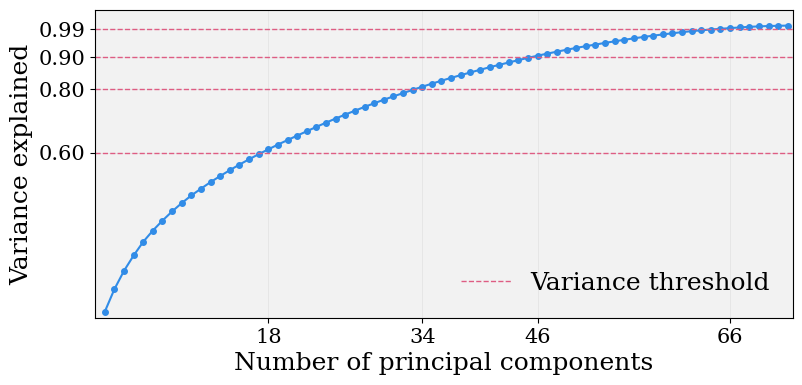

60% variance explained by 18 PCs
80% variance explained by 34 PCs
90% variance explained by 46 PCs
95% variance explained by 54 PCs
99% variance explained by 66 PCs


In [6]:
pca = PCA()
pca.fit(X_train_s)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.rcParams["font.family"] = "serif"

pca_color = "#318CE7"
threshold_color = "#DE5D83"
# threshold_color = "#CB4154"

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(cumulative) + 1), cumulative, marker="o", markersize=4,
         color=pca_color,
         # label="Number of principal components"
        )
plt.axhline(0.60, linestyle="--", linewidth=1, color=threshold_color,
            label="Variance threshold")
plt.axhline(0.80, linestyle="--", linewidth=1, color=threshold_color)
plt.axhline(0.90, linestyle="--", linewidth=1, color=threshold_color)
plt.axhline(0.99, linestyle="--", linewidth=1, color=threshold_color)

ax = plt.gca()
ax.set_facecolor("#f2f2f2")

ax.set_xlim([0, 72.5])
ax.set_ylim([0.08, 1.05])
ax.grid(True, linewidth=0.4, alpha=0.3)
ax.set_xlabel("Number of principal components", fontsize=18)
ax.set_ylabel("Variance explained", fontsize=18)

plt.yticks([0.6, 0.8, 0.9, 0.99])
plt.xticks([18, 34, 46, 66])
#plt.grid(True)

ax.tick_params(axis='both', labelsize=15)

plt.legend(frameon=False, fontsize=18)

plt.savefig("Results/PCA_train.pdf", bbox_inches="tight")

plt.show()

for threshold in [0.60, 0.80, 0.90, 0.95, 0.99]:
    k = np.searchsorted(cumulative, threshold) + 1
    print(f"{threshold:.0%} variance explained by {k} PCs")

#### Interpretation
* 34 PCs explain 80% variance;
* 46 PCs explain 90% variance;
* 54 PCS explain 95% variance;

This means that the data are genuinely high-dimensional. The low-rank rollout geometry is not already present in the data, and it is created by the transformer.

## Experiment 2: PCA feature importance

**What are we measuring?**

For each feature, we use the principal components $(\sigma_k,v_k)$ to compute

*Energy score:* $\displaystyle r_j = \sum_{k=1}^d\sigma_k |v_{jk}|^2$

**Scientific question:** which biomarkers dominate the natural variance structure of the metabolomic dataset?

In [4]:
K = np.searchsorted(cumulative, 0.90) + 1

eigenvalues = pca.explained_variance_[:K]   # lambda_k
components = pca.components_[:K, :]         # W_k, shape K x d

loadings = pca.components_[:K, :]          # shape: K x d
weights = explained[:K]                   # shape: K

pca_scores = np.sum(weights[:, None] * np.abs(loadings), axis=0)
pca_energy_scores = np.sum(eigenvalues[:, None] * components**2, axis=0)

# pca_importance = pd.DataFrame({
#     "feature": feature_names,
#     "PCA_score": pca_scores
# }).sort_values("PCA_score", ascending=False)

pca_energy_importance = pd.DataFrame({
    "feature": feature_names,
    "PCA_energy_score": pca_scores
}).sort_values("PCA_energy_score", ascending=False)

# pca_importance.head(5)
pca_energy_importance.head(10)

,feature,PCA_energy_score
66,Triglycerides (mg/dl),0.092488
32,Glucose (mM),0.089846
70,Urea (mg/dl),0.089816
7,Acetone (mM),0.089623
35,Glutamine to glutamate ratio (unitless),0.089365
4,3-Hydroxyisobutyric acid (mM),0.089114
60,SPC (mM),0.089045
39,Glycine (mM),0.089012
64,Threonine (mM),0.088394
30,Ethanol (mM),0.088334


In [5]:
df_energy = pd.DataFrame({'feature': feature_names,
                          'score': pca_energy_scores,
                          'original_position': range(len(feature_names))
                       })

df_sorted_energy = df_energy.sort_values(by='score', ascending=False).reset_index(drop=True)
df_sorted_energy['ranking'] = np.arange(1, len(feature_names)+1)

df_energy.to_csv(f"Results/feature_rankings/pcs_scores_unsorted.csv", 
      index=False, float_format="%.6f")

df_sorted_energy.to_csv(f"Results/feature_rankings/pcs_scores.csv", 
      index=False, float_format="%.6f")

In [103]:
pca_comparison = pd.DataFrame({
    "feature": feature_names,
    # "PCA_loading_score": pca_scores,
    "PCA_score": pca_energy_scores
})

# pca_comparison["loading_rank"] = pca_comparison["PCA_loading_score"].rank(ascending=False)
pca_comparison["energy_rank"] = pca_comparison["PCA_score"].rank(ascending=False)

pca_comparison.sort_values("energy_rank").head(5)

,feature,PCA_score,energy_rank
24,D-Galactose (mM),0.999189,1.0
26,Dimethylsulfone (mM),0.999046,2.0
53,"N,N-Dimethylglycine (mM)",0.998064,3.0
11,Arginine (mM),0.991575,4.0
13,Aspartate (mM),0.990805,5.0


#### Interpretation

**Participation** (L1) **score:** measures how strongly feature $j$ participates in the dominant variance modes. A feature gets a large score if it appears repeatedly across many important PCs.

Thus the L1 score identifies **variables broadly involved in the geometry of the data**.

**Energy** (L2) **score:** measures how much variance energy carried by the dominant PCs is associated with feature $j$. Because of the square, it rewards concentration.

More generally:
* L1 favors spread participation.
* L2 favors concentrated participation.

##### Large L1 and large L2
Feature appears strongly and consistently in dominant PCs. 

**Interpretation:** core structural biomarker. These are the variables driving the main geometry of the metabolomic data.

##### Large L1 but moderate L2

Feature appears in many dominant PCs but never dominates one. 

**Interpretation:** distributed biomarker. It participates broadly in the data structure. Think of it as a connector variable.

##### Small L1 but large L2

Feature appears almost exclusively in one dominant PC.

**Interpretation:** specialized biomarker. It defines a specific variance direction.

## Experiment 3: PCA vs a posteriori importance

**What are we measuring?** 

Correlation between $I^{PCA}$, $I^{en}$, $I^{rollout}$, $I^{spectral}$ and $I^{SHAP}$.

**Scientific question 1:** does attention concentrate information around variables that are already important in the data?

**Scientific question 2:** (only for comparison with SHAP) are the variables that vary most across individuals also the variables used for age prediction?

In [105]:
l = 11

rollout_df = pd.read_csv(f"Results/attention_scores/{l}layers/attention_scores{l}layers_unsorted.csv")
spectral_df = pd.read_csv(f"Results/attention_scores/{l}layers/pca_scores{l}layers_unsorted.csv")
shap_df = pd.read_csv(f"Results/shap_values/tables/{l}layers/shap_scores{l}layers_unsorted.csv")  

rollout_scores = rollout_df["score"].values
spectral_scores = spectral_df["score"].values
shap_scores = shap_df["score"].values

scores_df = pd.DataFrame({
    "feature": feature_names,
    # "PCA": pca_scores,
    "PCA": pca_energy_scores,
    "Rollout": rollout_scores,
    "Spectral": spectral_scores,
    "SHAP": shap_scores
})

scores_df.head()

,feature,PCA,Rollout,Spectral,SHAP
0,"1,5-Anhydrosorbitol (mM)",0.956880,1.255141,0.021880,0.096567
1,2-Aminobutyric acid (mM),0.913216,0.930079,0.012015,0.027073
2,2-Hydroxybutyric acid (mM),0.860790,0.775531,0.008354,0.015863
3,2-Oxoglutaric acid (mM),0.986584,0.851386,0.010068,0.015739
4,3-Hydroxyisobutyric acid (mM),0.852723,1.046446,0.015209,0.093188


In [106]:
def normalize(v):
    v = np.asarray(v)
    return (v - v.min()) / (v.max() - v.min() + 1e-12)

scores_df_norm = scores_df.copy()

for col in ["PCA", "Rollout", "Spectral", "SHAP"]:
    scores_df_norm[col] = normalize(scores_df[col])

scores_df_norm.head()

,feature,PCA,Rollout,Spectral,SHAP
0,"1,5-Anhydrosorbitol (mM)",0.789981,0.547073,0.441272,0.600859
1,2-Aminobutyric acid (mM),0.573232,0.231557,0.155595,0.149124
2,2-Hydroxybutyric acid (mM),0.312994,0.081548,0.049577,0.076256
3,2-Oxoglutaric acid (mM),0.937430,0.155175,0.099212,0.075449
4,3-Hydroxyisobutyric acid (mM),0.272950,0.344507,0.248089,0.578895


In [110]:
methods = ["PCA", "Rollout", "Spectral", "SHAP"]

corr_spearman = pd.DataFrame(index=methods, columns=methods, dtype=float)
corr_kendall = pd.DataFrame(index=methods, columns=methods, dtype=float)

for m1 in methods:
    for m2 in methods:
        corr_spearman.loc[m1, m2] = spearmanr(scores_df[m1], scores_df[m2]).correlation
        corr_kendall.loc[m1, m2] = kendalltau(scores_df[m1], scores_df[m2]).correlation

print("Spearman correlations")
display(corr_spearman)

# print("Kendall correlations")
# display(corr_kendall)

Spearman correlations


,PCA,Rollout,Spectral,SHAP
PCA,1.000000,-0.256801,-0.256224,-0.311692
Rollout,-0.256801,1.000000,0.999992,0.788668
Spectral,-0.256224,0.999992,1.000000,0.788337
SHAP,-0.311692,0.788668,0.788337,1.000000


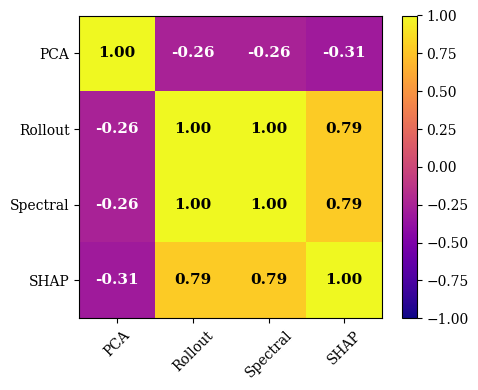

In [125]:
cmap = "plasma"
values = corr_spearman.to_numpy()
plt.figure(figsize=(5, 4))

plt.imshow(corr_spearman.astype(float), vmin=-1, vmax=1, cmap=cmap)


for i in range(values.shape[0]):
    for j in range(values.shape[1]):

        value = values[i, j]       

        # choose text color depending on intensity
        text_color = "white" if abs(value) < 0.6 else "black"
        # text_color = "black"

        plt.text(j, i, f"{value:.2f}", 
                 ha="center", va="center", 
                 fontsize=11, fontweight="bold",
                 color=text_color)

plt.colorbar()
plt.xticks(range(len(methods)), methods, rotation=45)
plt.yticks(range(len(methods)), methods)
plt.tight_layout()

# plt.savefig("Results/rankings.pdf", bbox_inches="tight")

plt.show()

#### Interpretation

**Low correlation** between a priori and a posteriori quantities. The transformer **discovers new propagation hubs**.

**Low correlation** between a priori quantities and SHAP. The model uses subtle signals that explain little variance but are highly predictive.

## Experiment 4: Rollout singular vectors vs PCA directions

**What are we measuring?**

We are computing $M_{ij}=|\langle V_i,W_j\rangle|$ where
* $V_i$ are the rollout singular vectors
* $W_j$ are the PCA directions.

**Scientific question:** do the dominant propagation modes coincide with the dominant statistical modes?

In [13]:
roll = np.load(f"Results/rollout_global/{l}layers/rollout{l}layers.npz")
R = roll["rollout"]

In [14]:
U, S, Vt = np.linalg.svd(R, full_matrices=False)

V_rollout = Vt.T              # right singular vectors
W_pca = pca.components_.T     # PCA directions

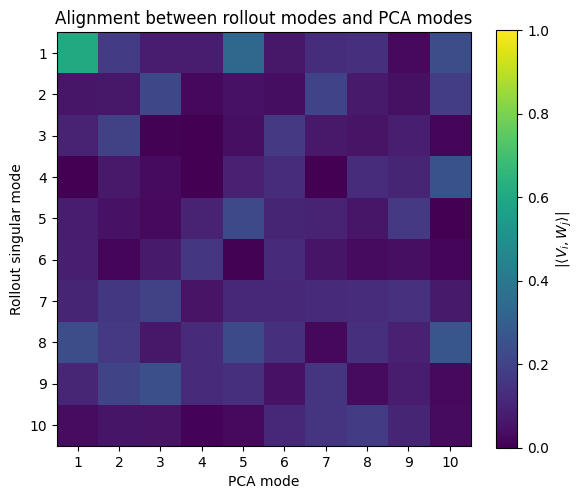

In [15]:
m = 10   # compare first 10 modes

alignment = np.abs(V_rollout[:, :m].T @ W_pca[:, :m])

plt.figure(figsize=(6, 5))
plt.imshow(alignment, vmin=0, vmax=1)
plt.colorbar(label=r"$|\langle V_i, W_j\rangle|$")
plt.xlabel("PCA mode")
plt.ylabel("Rollout singular mode")
plt.title("Alignment between rollout modes and PCA modes")
plt.xticks(range(m), range(1, m + 1))
plt.yticks(range(m), range(1, m + 1))
plt.tight_layout()
plt.show()

#### Interpretation

**Weak alignment:** the transformer learns a different geometry thatn that of the data.

## Experiment 5: effective rank comparison

**What are we measuring?** 

Compare $\text{erank}(X_{\text{test}})$ with $\text{erank}(R)$. 

**Scientific question:** is the rollout geometry more concentrated than the original data geometry?

In [29]:
def effective_rank_from_values(values):
    values = np.asarray(values)
    values = values[values > 1e-12]
    p = values / values.sum()
    return np.exp(-np.sum(p * np.log(p)))

pca_effective_rank = effective_rank_from_values(pca.explained_variance_)
rollout_effective_rank = effective_rank_from_values(S)

print("PCA effective rank:", pca_effective_rank)
print("Rollout effective rank:", rollout_effective_rank)

PCA effective rank: 45.33177
Rollout effective rank: 1.3294996


#### Interpretation

We find that $\text{erank}(R)\sim 1 \ll \text{erank}(X)\sim 45$. 

Then the transformer is compressing information into a few dominant propagation channels.

## Experiment 6: Common and emerging biomarkers

**What are we measuring?**

We classify variables into:

* **Group A:** important in PCA, Rollout and SHAP
* **Group B:** important in Rollout/SHAP but not PCA
* **Group C:** important in PCA but not in Rollout/SHAP

**Scientific meaning**
* **Group A:** core biomarkers. These are intrinsic to the data and remain important after learning.
* **Group B:** emergent biomarkers. These variables become important only after interaction learning. 
* **Group C:** variables that vary strongly in the population but are not useful for age prediction.

In [17]:
comparison = scores_df.copy()

for col in ["PCA", "PCA energy", "Rollout", "Spectral", "SHAP"]:
    comparison[f"{col}_rank"] = comparison[col].rank(ascending=False)

comparison = comparison.sort_values("PCA_rank")

In [18]:
comparison[
    ["feature", "PCA_rank", "PCA energy_rank", "Rollout_rank", "Spectral_rank", "SHAP_rank"]
].head(5)

,feature,PCA_rank,PCA energy_rank,Rollout_rank,Spectral_rank,SHAP_rank
66,Triglycerides (mg/dl),1.0,22.0,28.0,28.0,27.0
32,Glucose (mM),2.0,43.0,5.0,5.0,5.0
70,Urea (mg/dl),3.0,35.0,22.0,22.0,16.0
7,Acetone (mM),4.0,24.0,55.0,55.0,50.0
35,Glutamine to glutamate ratio (unitless),5.0,38.0,38.0,38.0,54.0


##### Features important in all methods

In [19]:
top_k = 10

common_top = comparison[
    (comparison["PCA_rank"] <= top_k) &
    (comparison["Rollout_rank"] <= top_k) &
    (comparison["SHAP_rank"] <= top_k)
]

common_top[["feature", "PCA_rank", "Rollout_rank", "SHAP_rank"]]

,feature,PCA_rank,Rollout_rank,SHAP_rank
32,Glucose (mM),2.0,5.0,5.0


In [20]:
common_top = comparison[
    (comparison["PCA energy_rank"] <= top_k) &
    (comparison["Rollout_rank"] <= top_k) &
    (comparison["SHAP_rank"] <= top_k)
]

common_top[["feature", "PCA energy_rank", "Rollout_rank", "SHAP_rank"]]

,feature,PCA energy_rank,Rollout_rank,SHAP_rank
26,Dimethylsulfone (mM),2.0,2.0,7.0


#### Features emerging only after training:

In [21]:
emergent_rollout = comparison[
    (comparison["PCA_rank"] > 20) &
    (comparison["Rollout_rank"] <= 10)
].sort_values("Rollout_rank")

emergent_rollout[["feature", "PCA_rank", "Rollout_rank", "SHAP_rank"]]

,feature,PCA_rank,Rollout_rank,SHAP_rank
9,Albumin (g/dl),36.0,1.0,1.0
26,Dimethylsulfone (mM),72.0,2.0,7.0
23,Cystine (mM),27.0,3.0,14.0
27,Erythrocyte sedimentation rate (mm/h),66.0,4.0,12.0
43,LDL cholesterol (mg/dl),22.0,6.0,2.0
0,"1,5-Anhydrosorbitol (mM)",42.0,7.0,3.0
69,Urate (mg/dl),55.0,9.0,6.0
18,Calcium (mg/dl),24.0,10.0,34.0


In [22]:
emergent_rollout = comparison[
    (comparison["PCA energy_rank"] > 20) &
    (comparison["Rollout_rank"] <= 10)
].sort_values("Rollout_rank")

emergent_rollout[["feature", "PCA energy_rank", "Rollout_rank", "SHAP_rank"]]

,feature,PCA energy_rank,Rollout_rank,SHAP_rank
9,Albumin (g/dl),47.0,1.0,1.0
23,Cystine (mM),46.0,3.0,14.0
27,Erythrocyte sedimentation rate (mm/h),57.0,4.0,12.0
32,Glucose (mM),43.0,5.0,5.0
43,LDL cholesterol (mg/dl),28.0,6.0,2.0
39,Glycine (mM),39.0,8.0,47.0
69,Urate (mg/dl),67.0,9.0,6.0
18,Calcium (mg/dl),44.0,10.0,34.0


#### Features important in PCA but not in model:

In [23]:
lost_features = comparison[
    (comparison["PCA_rank"] <= 10) &
    (comparison["Rollout_rank"] > 20) &
    (comparison["SHAP_rank"] > 20)
].sort_values("PCA_rank")

lost_features[["feature", "PCA_rank", "Rollout_rank", "SHAP_rank"]]

,feature,PCA_rank,Rollout_rank,SHAP_rank
66,Triglycerides (mg/dl),1.0,28.0,27.0
7,Acetone (mM),4.0,55.0,50.0
35,Glutamine to glutamate ratio (unitless),5.0,38.0,54.0
64,Threonine (mM),9.0,25.0,39.0
30,Ethanol (mM),10.0,62.0,40.0


In [24]:
lost_features = comparison[
    (comparison["PCA energy_rank"] <= 10) &
    (comparison["Rollout_rank"] > 20) &
    (comparison["SHAP_rank"] > 20)
].sort_values("PCA_rank")

lost_features[["feature", "PCA energy_rank", "Rollout_rank", "SHAP_rank"]]

,feature,PCA energy_rank,Rollout_rank,SHAP_rank
63,Succinic acid (mM),9.0,40.0,35.0
13,Aspartate (mM),5.0,69.0,68.0
31,Formic acid (mM),10.0,34.0,29.0
12,Asparagine (mM),7.0,57.0,52.0
3,2-Oxoglutaric acid (mM),8.0,54.0,58.0
11,Arginine (mM),4.0,71.0,70.0
48,Lipoprotein(a) (mg/dl),6.0,56.0,67.0
53,"N,N-Dimethylglycine (mM)",3.0,65.0,59.0
24,D-Galactose (mM),1.0,51.0,72.0
